In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import math
import seaborn as sns
import numpy as np


In [2]:
corporate_pacs = pd.read_csv("../data/cpac/corporate_pacs_2004_2024.csv", dtype={"PermID":str})
public_firms = pd.read_csv("../data/firms/public_firms.csv", dtype={"PermID":str})
private_firms = pd.read_csv("../data/firms/private_firms.csv", dtype={"PermID":str})

In [3]:
list_col = ["TRBC_ID", "TRBC_Econ_Sector", "TRBC_Business_Sector", "TRBC_Industry_Group",
            "TRBC_Industry", "TRBC_Activity", "NAICS_ID", "NAICS_Sector", "NAICS_Subsector",
            "NAICS_Industry_Group", "NAICS_International_Industry", "NAICS_National_Industry"]
for col in list_col:
    public_firms[col] = public_firms[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else None)
    private_firms[col] = private_firms[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else None)

In [4]:
cpac_public = corporate_pacs.loc[(~corporate_pacs["RIC"].isna()), ].reset_index(drop=True)
cpac_private = corporate_pacs.loc[(corporate_pacs["RIC"].isna()), ].reset_index(drop=True)
cpac_public = pd.merge(cpac_public[["CMTE_ID", "RIC", "PermID", "Parent", "Website", "YEAR"]],
                            public_firms,
                            how = "left",
                            left_on = "RIC", right_on = "Instrument",
                            suffixes = ("", "_public"))
cpac_private = pd.merge(cpac_private[["CMTE_ID", "RIC", "PermID", "Parent", "Website", "YEAR"]],
                            private_firms,
                            how = "left",
                            left_on = "PermID", right_on = "Instrument",
                            suffixes = ("", "_private"))
cpac = pd.concat([cpac_public, cpac_private]).reset_index(drop=True).drop(columns=["RIC_public", "PermID_public", "RIC_private", "PermID_private"])

In [8]:
def calc_hedge(df, col1, col2):
    a = df[col1]
    b = df[col2]
    return 1 - abs((a-b)/(a+b))

def calc_balance(df, col1, col2):
    a = df[col1]
    b = df[col2]
    return (a-b)/(a+b)

def count_unique(x):
    return len(set(x))

In [9]:
def get_hedge(year):
    cand = pd.read_parquet(f"../data/candidates/candidate_master_{year}.parquet")
    contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")

    contrib = contrib.loc[(contrib["TRANSACTION_TP"] == "24K"), ["CMTE_ID", "TRANSACTION_AMT", "CAND_ID", "YEAR", "MONTH", "DAY"]].reset_index(drop=True)
    cand = cand.loc[cand["CAND_ELECTION_YR"] >= year - 1, ["CAND_ID", "CAND_NAME", "CAND_PTY_AFFILIATION", "CAND_OFFICE_ST", "CAND_OFFICE", "CAND_OFFICE_DISTRICT", "CAND_ICI"]].reset_index(drop=True)

    contrib_pe = contrib.loc[
        (contrib["YEAR"] == year),# & (contrib["MONTH"].between(8, 10)),
    ].reset_index(drop=True)

    contrib_ppe = contrib.loc[
        (contrib["YEAR"] == year - 1),# | (contrib["MONTH"] < 8),
    ].reset_index(drop=True)

    contrib = pd.merge(contrib, cand,
                       how = "left", on = "CAND_ID")

    contrib_pe = pd.merge(contrib_pe, cand,
                          how = "left", on = "CAND_ID")
    
    contrib_ppe = pd.merge(contrib_ppe, cand,
                          how = "left", on = "CAND_ID")

    agg_dict = {col: 'sum' if col == "TRANSACTION_AMT" else "first" for col in contrib.columns if col not in ["CMTE_ID", "CAND_ID"]}
    contrib = contrib.groupby(["CMTE_ID", "CAND_ID"], as_index=False).agg(agg_dict)

    agg_dict = {col: 'sum' if col == "TRANSACTION_AMT" else "first" for col in contrib_pe.columns if col not in ["CMTE_ID", "CAND_ID"]}
    contrib_pe = contrib_pe.groupby(["CMTE_ID", "CAND_ID"], as_index=False).agg(agg_dict)

    agg_dict = {col: 'sum' if col == "TRANSACTION_AMT" else "first" for col in contrib_ppe.columns if col not in ["CMTE_ID", "CAND_ID"]}
    contrib_ppe = contrib_ppe.groupby(["CMTE_ID", "CAND_ID"], as_index=False).agg(agg_dict)

    contrib = contrib.loc[contrib["TRANSACTION_AMT"] > 0,]
    contrib["CAND_PTY_AFFILIATION"] = contrib["CAND_PTY_AFFILIATION"].replace("DFL", "DEM")

    contrib_pe = contrib_pe.loc[contrib_pe["TRANSACTION_AMT"] > 0,]
    contrib_pe["CAND_PTY_AFFILIATION"] = contrib_pe["CAND_PTY_AFFILIATION"].replace("DFL", "DEM")

    contrib_ppe = contrib_ppe.loc[contrib_ppe["TRANSACTION_AMT"] > 0,]
    contrib_ppe["CAND_PTY_AFFILIATION"] = contrib_ppe["CAND_PTY_AFFILIATION"].replace("DFL", "DEM")

    partisan = contrib.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count="count", total="sum")
    incumbent = contrib.groupby(["CMTE_ID", "CAND_ICI", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count = "count", total = "sum")

    partisan_pe = contrib_pe.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count="count", total="sum")
    incumbent_pe = contrib_pe.groupby(["CMTE_ID", "CAND_ICI", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count = "count", total = "sum")

    partisan_ppe = contrib_ppe.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count="count", total="sum")
    incumbent_ppe = contrib_ppe.groupby(["CMTE_ID", "CAND_ICI", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count = "count", total = "sum")

    partisan = partisan[partisan["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])]
    partisan_pe = partisan_pe[partisan_pe["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])]
    partisan_ppe = partisan_ppe[partisan_ppe["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])]

    hedge_party = partisan.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(fill_value=0)
    hedge_chamber = partisan.groupby(["CMTE_ID", "CAND_OFFICE", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(["CAND_OFFICE", "CAND_PTY_AFFILIATION"], fill_value=0)

    hedge_party_pe = partisan_pe.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(fill_value=0)
    hedge_chamber_pe = partisan_pe.groupby(["CMTE_ID", "CAND_OFFICE", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(["CAND_OFFICE", "CAND_PTY_AFFILIATION"], fill_value=0)

    hedge_party_ppe = partisan_ppe.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(fill_value=0)
    hedge_chamber_ppe = partisan_ppe.groupby(["CMTE_ID", "CAND_OFFICE", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(["CAND_OFFICE", "CAND_PTY_AFFILIATION"], fill_value=0)

    hedge_party.columns = [f'{val}_{col}' for col, val in hedge_party.columns]
    hedge_party = hedge_party.reset_index()
    hedge_chamber.columns = [f'{val1}_{val2}_{col}' for col, val1, val2 in hedge_chamber.columns]
    hedge_chamber = hedge_chamber.reset_index()

    hedge_party_pe.columns = [f'{val}_{col}' for col, val in hedge_party_pe.columns]
    hedge_party_pe = hedge_party_pe.reset_index()
    hedge_chamber_pe.columns = [f'{val1}_{val2}_{col}' for col, val1, val2 in hedge_chamber_pe.columns]
    hedge_chamber_pe = hedge_chamber_pe.reset_index()

    hedge_party_ppe.columns = [f'{val}_{col}' for col, val in hedge_party_ppe.columns]
    hedge_party_ppe = hedge_party_ppe.reset_index()
    hedge_chamber_ppe.columns = [f'{val1}_{val2}_{col}' for col, val1, val2 in hedge_chamber_ppe.columns]
    hedge_chamber_ppe = hedge_chamber_ppe.reset_index()

    hedge_party["hedge_count"] = calc_hedge(hedge_party, "DEM_count", "REP_count")
    hedge_party["hedge_amount"] = calc_hedge(hedge_party, "DEM_total", "REP_total")
    hedge_chamber["house_hedge_count"] = calc_hedge(hedge_chamber, "H_DEM_count", "H_REP_count")
    hedge_chamber["house_hedge_amount"] = calc_hedge(hedge_chamber, "H_DEM_total", "H_REP_total")
    hedge_chamber["senate_hedge_count"] = calc_hedge(hedge_chamber, "S_DEM_count", "S_REP_count")
    hedge_chamber["senate_hedge_amount"] = calc_hedge(hedge_chamber, "S_DEM_total", "S_REP_total")

    hedge_party["balance_count"] = calc_balance(hedge_party, "DEM_count", "REP_count")
    hedge_party["balance_amount"] = calc_balance(hedge_party, "DEM_total", "REP_total")
    hedge_chamber["house_balance_count"] = calc_balance(hedge_chamber, "H_DEM_count", "H_REP_count")
    hedge_chamber["house_balance_amount"] = calc_balance(hedge_chamber, "H_DEM_total", "H_REP_total")
    hedge_chamber["senate_balance_count"] = calc_balance(hedge_chamber, "S_DEM_count", "S_REP_count")
    hedge_chamber["senate_balance_amount"] = calc_balance(hedge_chamber, "S_DEM_total", "S_REP_total")

    hedge_party_pe["hedge_count"] = calc_hedge(hedge_party_pe, "DEM_count", "REP_count")
    hedge_party_pe["hedge_amount"] = calc_hedge(hedge_party_pe, "DEM_total", "REP_total")
    hedge_chamber_pe["house_hedge_count"] = calc_hedge(hedge_chamber_pe, "H_DEM_count", "H_REP_count")
    hedge_chamber_pe["house_hedge_amount"] = calc_hedge(hedge_chamber_pe, "H_DEM_total", "H_REP_total")
    hedge_chamber_pe["senate_hedge_count"] = calc_hedge(hedge_chamber_pe, "S_DEM_count", "S_REP_count")
    hedge_chamber_pe["senate_hedge_amount"] = calc_hedge(hedge_chamber_pe, "S_DEM_total", "S_REP_total")

    hedge_party_pe["balance_count"] = calc_balance(hedge_party_pe, "DEM_count", "REP_count")
    hedge_party_pe["balance_amount"] = calc_balance(hedge_party_pe, "DEM_total", "REP_total")
    hedge_chamber_pe["house_balance_count"] = calc_balance(hedge_chamber_pe, "H_DEM_count", "H_REP_count")
    hedge_chamber_pe["house_balance_amount"] = calc_balance(hedge_chamber_pe, "H_DEM_total", "H_REP_total")
    hedge_chamber_pe["senate_balance_count"] = calc_balance(hedge_chamber_pe, "S_DEM_count", "S_REP_count")
    hedge_chamber_pe["senate_balance_amount"] = calc_balance(hedge_chamber_pe, "S_DEM_total", "S_REP_total")

    hedge_party_ppe["hedge_count"] = calc_hedge(hedge_party_ppe, "DEM_count", "REP_count")
    hedge_party_ppe["hedge_amount"] = calc_hedge(hedge_party_ppe, "DEM_total", "REP_total")
    hedge_chamber_ppe["house_hedge_count"] = calc_hedge(hedge_chamber_ppe, "H_DEM_count", "H_REP_count")
    hedge_chamber_ppe["house_hedge_amount"] = calc_hedge(hedge_chamber_ppe, "H_DEM_total", "H_REP_total")
    hedge_chamber_ppe["senate_hedge_count"] = calc_hedge(hedge_chamber_ppe, "S_DEM_count", "S_REP_count")
    hedge_chamber_ppe["senate_hedge_amount"] = calc_hedge(hedge_chamber_ppe, "S_DEM_total", "S_REP_total")

    hedge_party_ppe["balance_count"] = calc_balance(hedge_party_ppe, "DEM_count", "REP_count")
    hedge_party_ppe["balance_amount"] = calc_balance(hedge_party_ppe, "DEM_total", "REP_total")
    hedge_chamber_ppe["house_balance_count"] = calc_balance(hedge_chamber_ppe, "H_DEM_count", "H_REP_count")
    hedge_chamber_ppe["house_balance_amount"] = calc_balance(hedge_chamber_ppe, "H_DEM_total", "H_REP_total")
    hedge_chamber_ppe["senate_balance_count"] = calc_balance(hedge_chamber_ppe, "S_DEM_count", "S_REP_count")
    hedge_chamber_ppe["senate_balance_amount"] = calc_balance(hedge_chamber_ppe, "S_DEM_total", "S_REP_total")

    hedge = pd.merge(hedge_party, hedge_chamber, how = "left", on = "CMTE_ID")
    hedge_pe = pd.merge(hedge_party_pe, hedge_chamber_pe, how = "left", on = "CMTE_ID")
    hedge_ppe = pd.merge(hedge_party_ppe, hedge_chamber_ppe, how = "left", on = "CMTE_ID")

    hedge = hedge[["CMTE_ID", "hedge_count", "hedge_amount",
                   "house_hedge_count", "house_hedge_amount",
                   "senate_hedge_count", "senate_hedge_amount",
                   "balance_count", "balance_amount",
                   "house_balance_count", "house_balance_amount",
                   "senate_balance_count", "senate_balance_amount"]]

    hedge_pe = hedge_pe[["CMTE_ID", "hedge_count", "hedge_amount",
                         "house_hedge_count", "house_hedge_amount",
                         "senate_hedge_count", "senate_hedge_amount",
                         "balance_count", "balance_amount",
                         "house_balance_count", "house_balance_amount",
                         "senate_balance_count", "senate_balance_amount"]]

    hedge_ppe = hedge_ppe[["CMTE_ID", "hedge_count", "hedge_amount",
                           "house_hedge_count", "house_hedge_amount",
                           "senate_hedge_count", "senate_hedge_amount",
                           "balance_count", "balance_amount",
                           "house_balance_count", "house_balance_amount",
                           "senate_balance_count", "senate_balance_amount"]]


    contrib_sum = contrib.groupby("CMTE_ID", as_index=False)["TRANSACTION_AMT"].agg("sum")
    contrib_sum.columns = ["CMTE_ID", "contribute_sum"]
    diverse = contrib.dropna(subset="CAND_OFFICE_ST").groupby("CMTE_ID", as_index=False)[["CAND_OFFICE_ST", "CAND_NAME"]].agg(count_unique)
    diverse.columns = ["CMTE_ID", "n_states", "n_cands"]

    contrib_sum_pe = contrib_pe.groupby("CMTE_ID", as_index=False)["TRANSACTION_AMT"].agg("sum")
    contrib_sum_pe.columns = ["CMTE_ID", "contribute_sum"]
    diverse_pe = contrib_pe.dropna(subset="CAND_OFFICE_ST").groupby("CMTE_ID", as_index=False)[["CAND_OFFICE_ST", "CAND_NAME"]].agg(count_unique)
    diverse_pe.columns = ["CMTE_ID", "n_states", "n_cands"]

    contrib_sum_ppe = contrib_ppe.groupby("CMTE_ID", as_index=False)["TRANSACTION_AMT"].agg("sum")
    contrib_sum_ppe.columns = ["CMTE_ID", "contribute_sum"]
    diverse_ppe = contrib_ppe.dropna(subset="CAND_OFFICE_ST").groupby("CMTE_ID", as_index=False)[["CAND_OFFICE_ST", "CAND_NAME"]].agg(count_unique)
    diverse_ppe.columns = ["CMTE_ID", "n_states", "n_cands"]

    hedge = pd.merge(hedge, contrib_sum, how = "left", on = "CMTE_ID")
    hedge = pd.merge(hedge, diverse, how = "left", on = "CMTE_ID")
    hedge_pe = pd.merge(hedge_pe, contrib_sum_pe, how = "left", on = "CMTE_ID")
    hedge_pe = pd.merge(hedge_pe, diverse_pe, how = "left", on = "CMTE_ID")
    hedge_ppe = pd.merge(hedge_ppe, contrib_sum_ppe, how = "left", on = "CMTE_ID")
    hedge_ppe = pd.merge(hedge_ppe, diverse_ppe, how = "left", on = "CMTE_ID")

    return hedge, hedge_pe, hedge_ppe

In [10]:
a,b,c = get_hedge(2024)

C:\Users\zih028\AppData\Local\Temp\ipykernel_15212\478319296.py:3: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")


In [11]:
a

,CMTE_ID,hedge_count,hedge_amount,house_hedge_count,house_hedge_amount,senate_hedge_count,senate_hedge_amount,balance_count,balance_amount,house_balance_count,house_balance_amount,senate_balance_count,senate_balance_amount,contribute_sum,n_states,n_cands
0,C00000059,0.962963,0.912500,0.857143,0.968750,0.666667,0.437500,-0.037037,0.087500,-0.142857,-0.031250,0.333333,0.562500,80000.0,13,27
1,C00002790,0.100000,0.121212,0.133333,0.155039,0.000000,0.000000,-0.900000,-0.878788,-0.866667,-0.844961,-1.000000,-1.000000,82500.0,13,20
2,C00003251,0.027972,0.020669,0.030651,0.023296,0.000000,0.000000,0.972028,0.979331,0.969349,0.976704,1.000000,1.000000,1700000.0,47,289
3,C00004952,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,25000.0,1,4
4,C00007070,0.920000,0.862069,1.000000,0.903226,0.666667,0.695652,-0.080000,-0.137931,0.000000,-0.096774,-0.333333,-0.304348,123000.0,25,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,C00882068,0.666667,0.666667,0.666667,0.666667,NaN,NaN,-0.333333,-0.333333,-0.333333,-0.333333,NaN,NaN,3000.0,3,3
893,C00883645,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1000.0,1,1
894,C00884767,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,2500.0,1,1
895,C00888842,0.200000,0.222222,0.333333,0.380952,0.000000,0.000000,-0.800000,-0.777778,-0.666667,-0.619048,-1.000000,-1.000000,18000.0,10,10


In [14]:
cpac_hedge = cpac
cpac_hedge_pe = cpac
cpac_hedge_ppe = cpac

merge_cols = ["hedge_count", "hedge_amount",
              "house_hedge_count", "house_hedge_amount",
              "senate_hedge_count", "senate_hedge_amount",
              "balance_count", "balance_amount",
              "house_balance_count", "house_balance_amount",
              "senate_balance_count", "senate_balance_amount",
              "contribute_sum", "n_states", "n_cands"]

for i in range(2004, 2026, 2):
    hedge, hedge_pe, hedge_ppe = get_hedge(i)
    hedge["YEAR"] = i
    hedge_pe["YEAR"] = i
    hedge_ppe["YEAR"] = i
    cpac_hedge = pd.merge(cpac_hedge, hedge, how = "left", on = ["CMTE_ID", "YEAR"], suffixes = ("", "_new"))
    cpac_hedge_pe = pd.merge(cpac_hedge_pe, hedge_pe, how = "left", on = ["CMTE_ID", "YEAR"], suffixes = ("", "_new"))
    cpac_hedge_ppe = pd.merge(cpac_hedge_ppe, hedge_ppe, how = "left", on = ["CMTE_ID", "YEAR"], suffixes = ("", "_new"))

    if "hedge_count_new" in cpac_hedge.columns:
        for col in merge_cols:
            cpac_hedge[col] = cpac_hedge[col].fillna(cpac_hedge[f"{col}_new"])
            cpac_hedge.drop(columns = f"{col}_new", inplace=True)

    if "hedge_count_new" in cpac_hedge_pe.columns:
        for col in merge_cols:
            cpac_hedge_pe[col] = cpac_hedge_pe[col].fillna(cpac_hedge_pe[f"{col}_new"])
            cpac_hedge_pe.drop(columns = f"{col}_new", inplace=True)

    if "hedge_count_new" in cpac_hedge_ppe.columns:
        for col in merge_cols:
            cpac_hedge_ppe[col] = cpac_hedge_ppe[col].fillna(cpac_hedge_ppe[f"{col}_new"])
            cpac_hedge_ppe.drop(columns = f"{col}_new", inplace=True)


C:\Users\zih028\AppData\Local\Temp\ipykernel_15172\613882092.py:3: DtypeWarning: Columns (10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")
C:\Users\zih028\AppData\Local\Temp\ipykernel_15172\613882092.py:3: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")
C:\Users\zih028\AppData\Local\Temp\ipykernel_15172\613882092.py:3: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")
C:\Users\zih028\AppData\Local\Temp\ipykernel_15172\613882092.py:3: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/comm

In [15]:
cpac_hedge.to_csv("../data/hedging/cpac_hedging_full.csv", index=False)
cpac_hedge_pe.to_csv("../data/hedging/cpac_hedging_full_preelection_11m.csv", index=False)
cpac_hedge_ppe.to_csv("../data/hedging/cpac_hedging_full_prepreelection_12m.csv", index=False)

In [21]:
hedge_2024, hedge_pe_2024, hedge_ppe_2024 = get_hedge(2024)

C:\Users\zih028\AppData\Local\Temp\ipykernel_15172\613882092.py:3: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")


In [29]:
cpac_2024 = cpac[cpac["YEAR"] == 2024]
cpac_hedge_2024 = cpac_2024.merge(hedge_2024, how = "left", on = "CMTE_ID", suffixes = ("", "_new"))
cpac_hedge_pe_2024 = cpac_2024.merge(hedge_pe_2024, how = "left", on = "CMTE_ID", suffixes = ("", "_new"))
cpac_hedge_ppe_2024 = cpac_2024.merge(hedge_ppe_2024, how = "left", on = "CMTE_ID", suffixes = ("", "_new"))

In [30]:
cpac_hedge_2024.to_csv("../data/hedging/cpac_hedging_20232024.csv", index=False)
cpac_hedge_pe_2024.to_csv("../data/hedging/cpac_hedging_2024.csv", index=False)
cpac_hedge_ppe_2024.to_csv("../data/hedging/cpac_hedging_2023.csv", index=False)

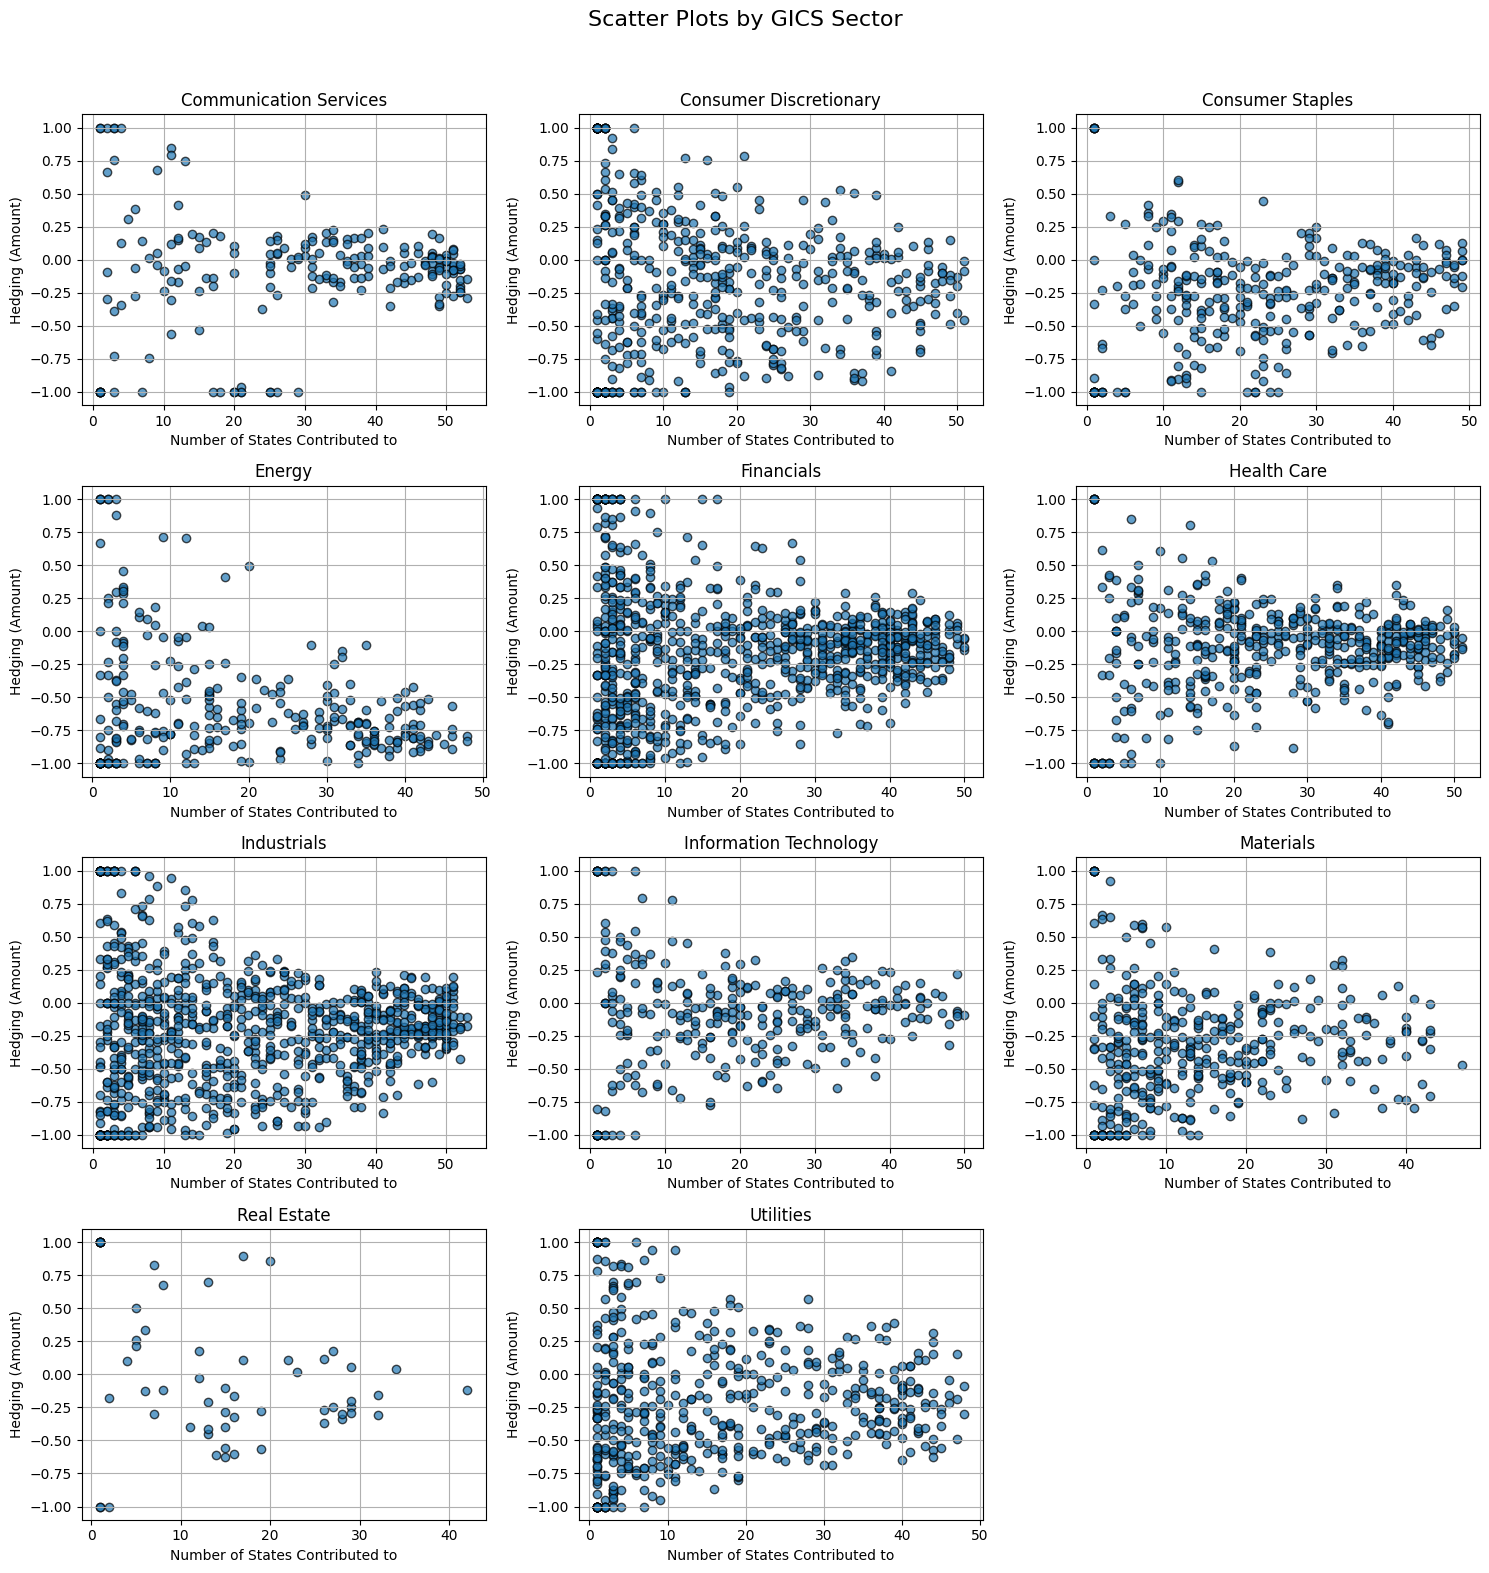

In [20]:
sectors = cpac_hedge['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = cpac_hedge[cpac_hedge['GICS_Sector'] == sector]
    ax.scatter(
        subset['n_states'],
        subset['balance_amount'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Number of States Contributed to')
    ax.set_ylabel('Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

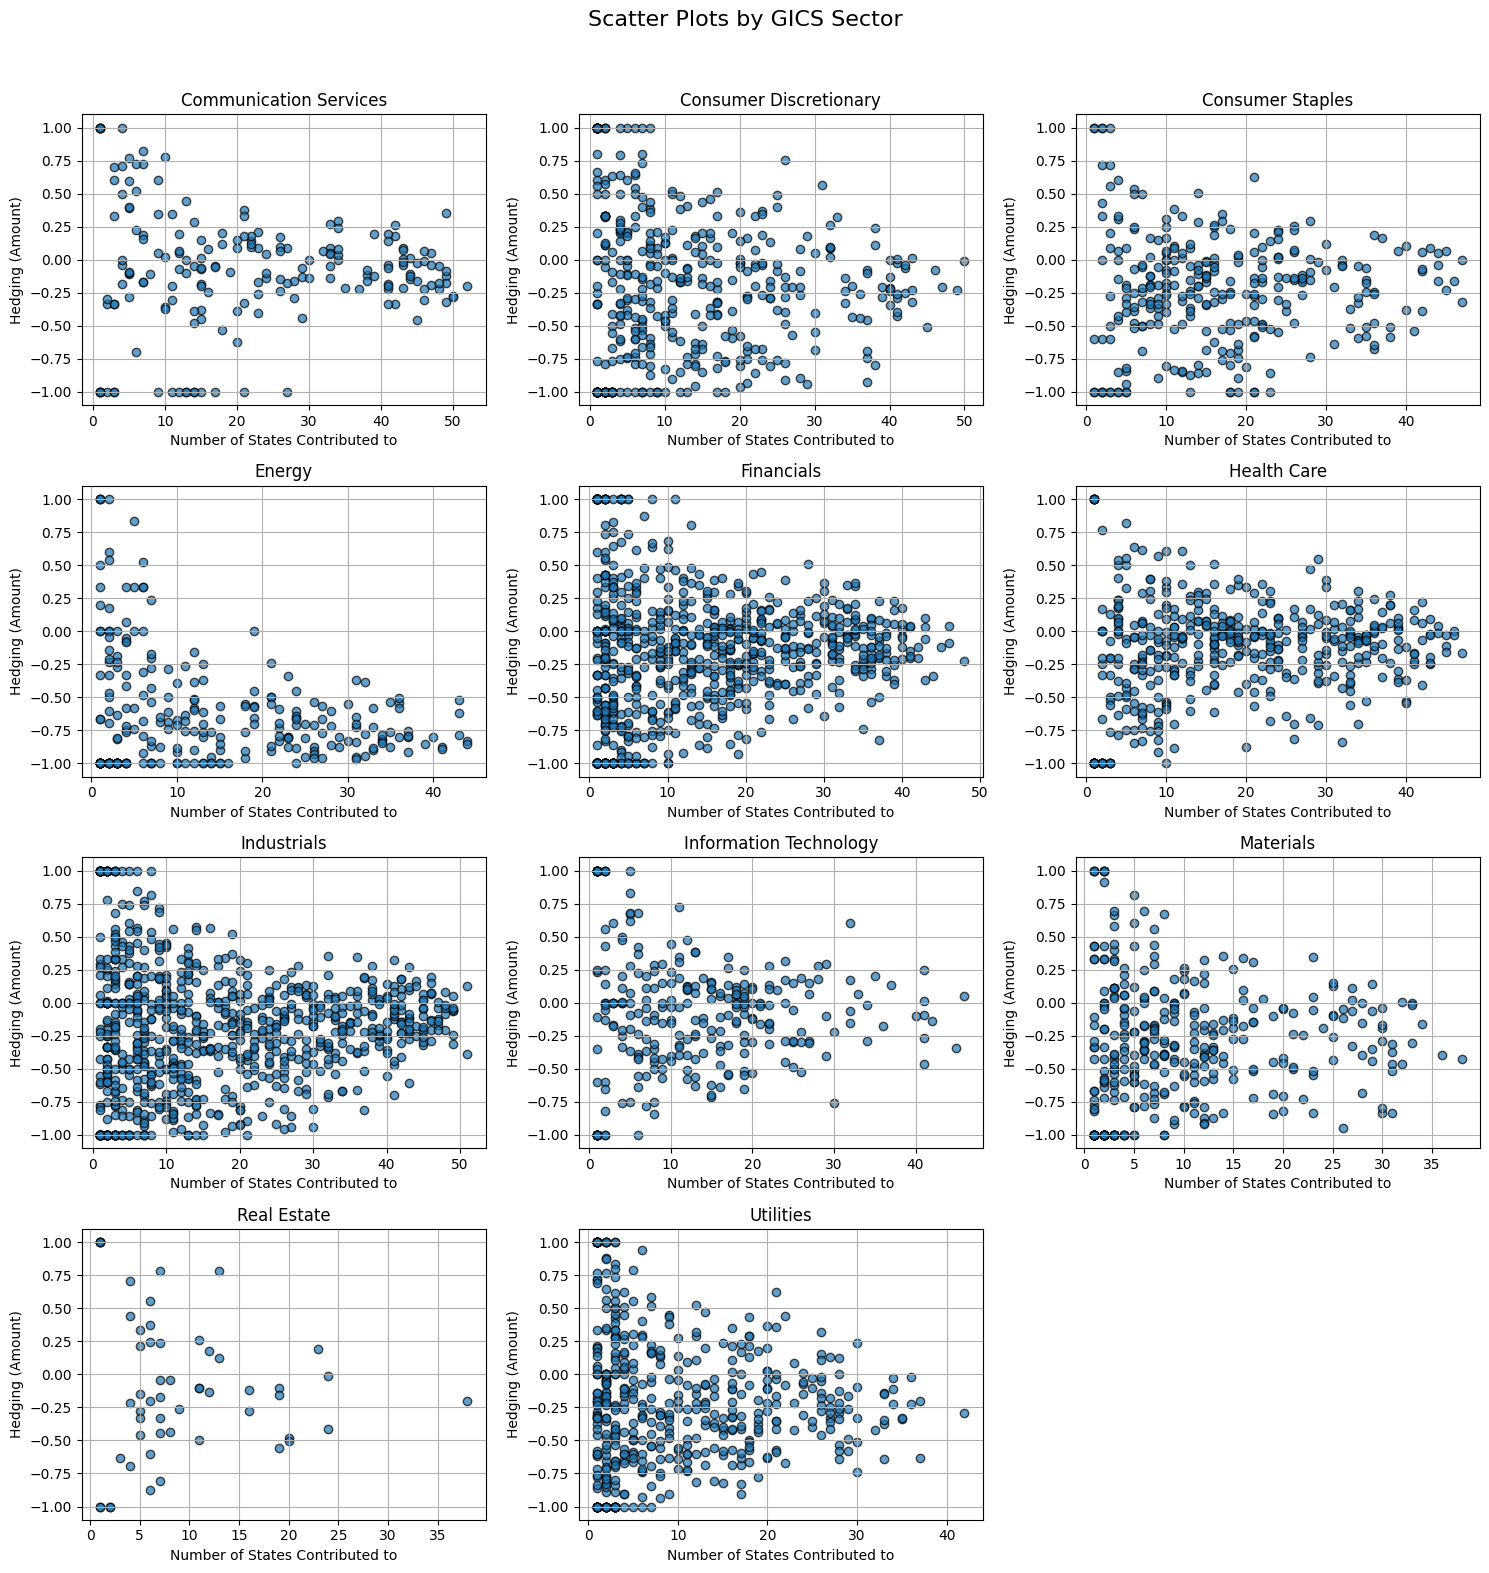

In [21]:
sectors = cpac_hedge_pe['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = cpac_hedge_pe[cpac_hedge_pe['GICS_Sector'] == sector]
    ax.scatter(
        subset['n_states'],
        subset['balance_amount'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Number of States Contributed to')
    ax.set_ylabel('Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

In [26]:
comparison = pd.merge(
    cpac_hedge_pe[["CMTE_ID", "YEAR", "GICS_Sector", "balance_amount", "balance_count"]],
    cpac_hedge_ppe[["CMTE_ID", "YEAR", "GICS_Sector", "balance_amount", "balance_count"]],
    how = "outer", on = ["CMTE_ID", "YEAR", "GICS_Sector"],
    suffixes = ("_pe", "_ppe")
)

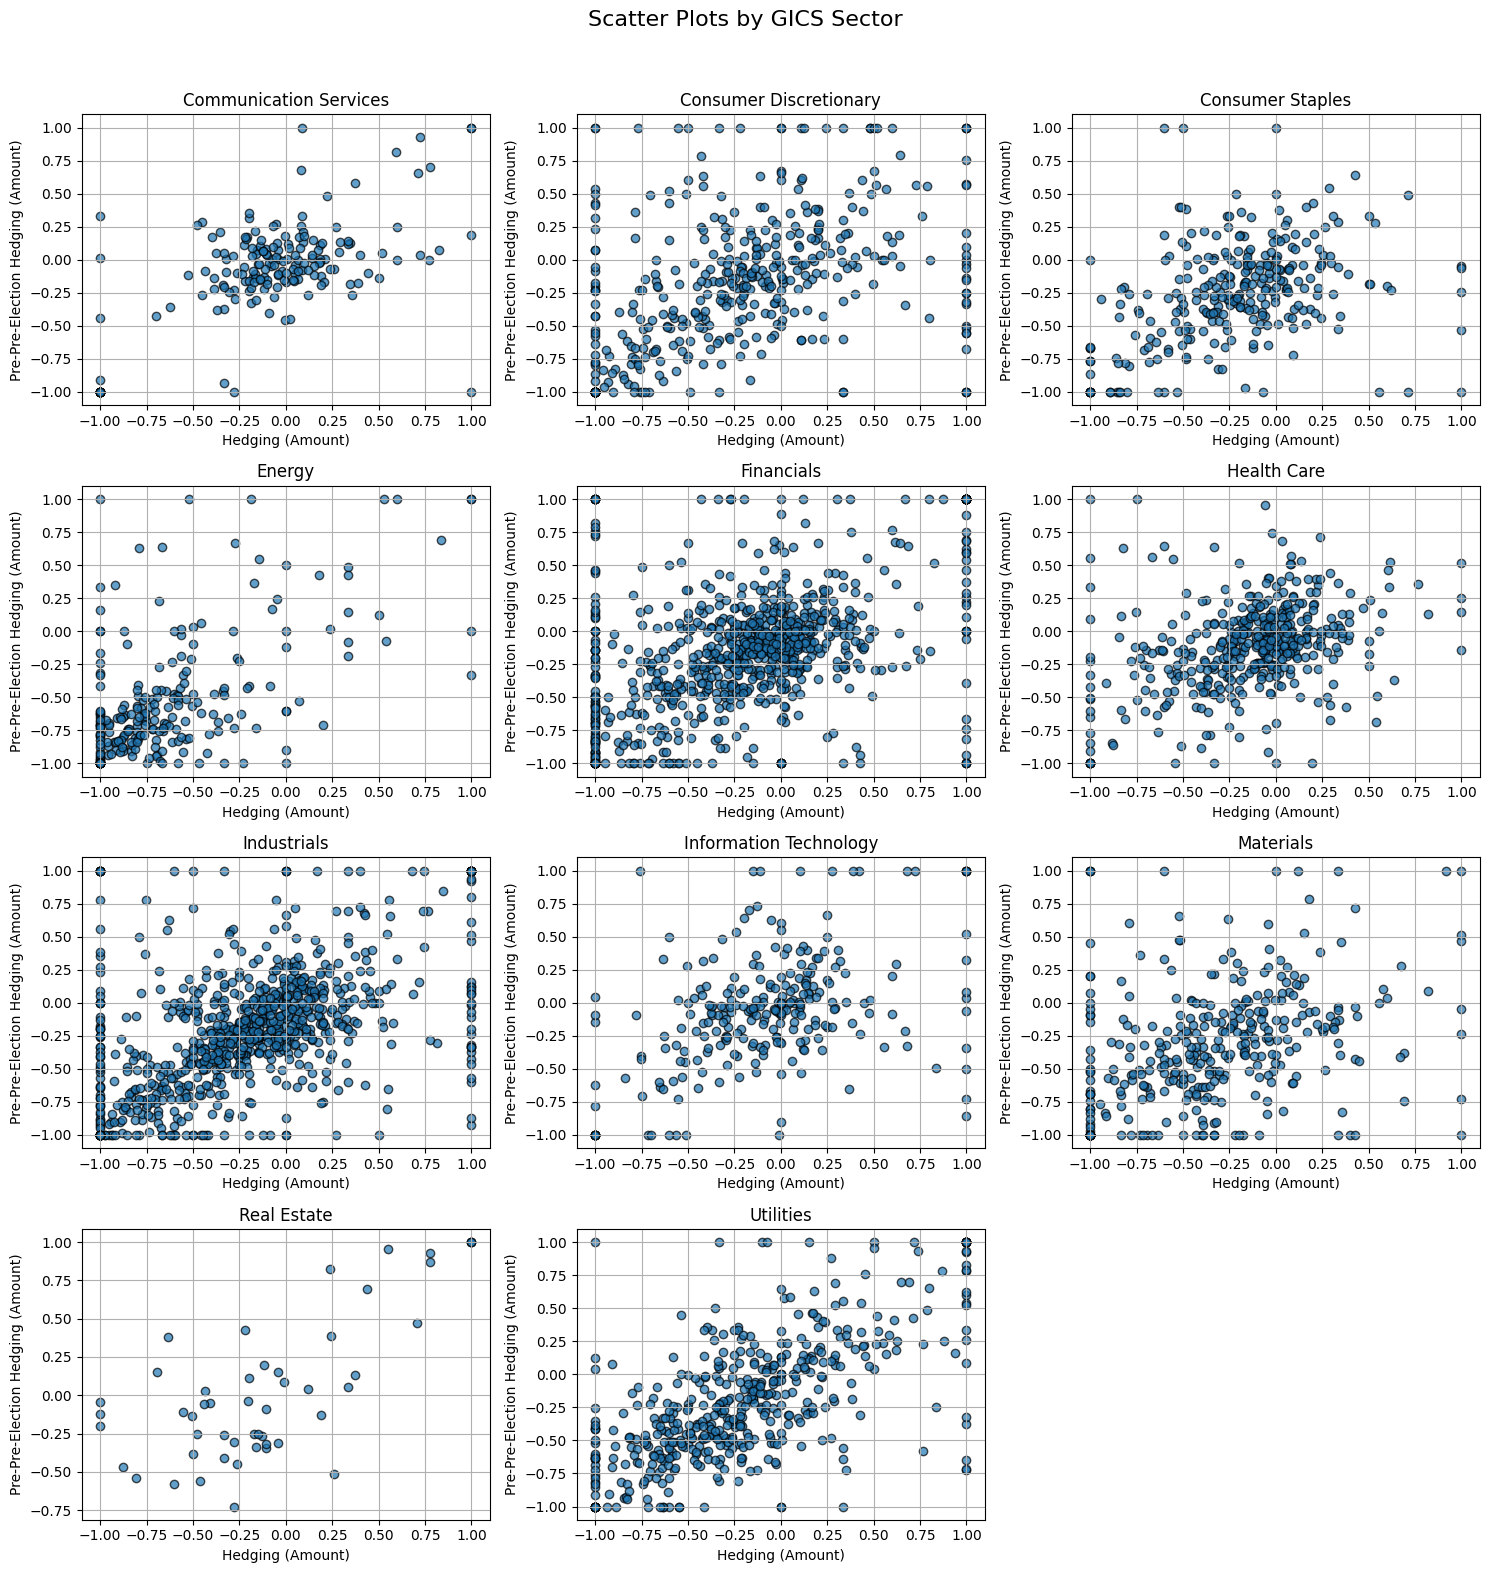

In [27]:
sectors = comparison['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = comparison[comparison['GICS_Sector'] == sector]
    ax.scatter(
        subset['balance_amount_pe'],
        subset['balance_amount_ppe'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Hedging (Amount)')
    ax.set_ylabel('Pre-Pre-Election Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

In [28]:
comparison

,CMTE_ID,YEAR,GICS_Sector,balance_amount_pe,balance_count_pe,balance_amount_ppe,balance_count_ppe
0,C00000042,2004,Industrials,-0.941176,-0.872340,-0.902913,-0.739130
1,C00000042,2006,Industrials,-1.000000,-1.000000,-0.889908,-0.826087
2,C00000042,2008,Industrials,-0.891892,-0.818182,-0.899160,-0.744681
3,C00000042,2010,Industrials,-0.951220,-0.906977,-0.919540,-0.837838
4,C00000042,2012,Industrials,-0.937984,-0.877551,-0.841808,-0.800000
...,...,...,...,...,...,...,...
14670,C00893925,2024,Energy,NaN,NaN,NaN,NaN
14671,C00893933,2024,NaN,NaN,NaN,NaN,NaN
14672,C00894055,2024,NaN,NaN,NaN,NaN,NaN
14673,C00894196,2024,Industrials,NaN,NaN,NaN,NaN


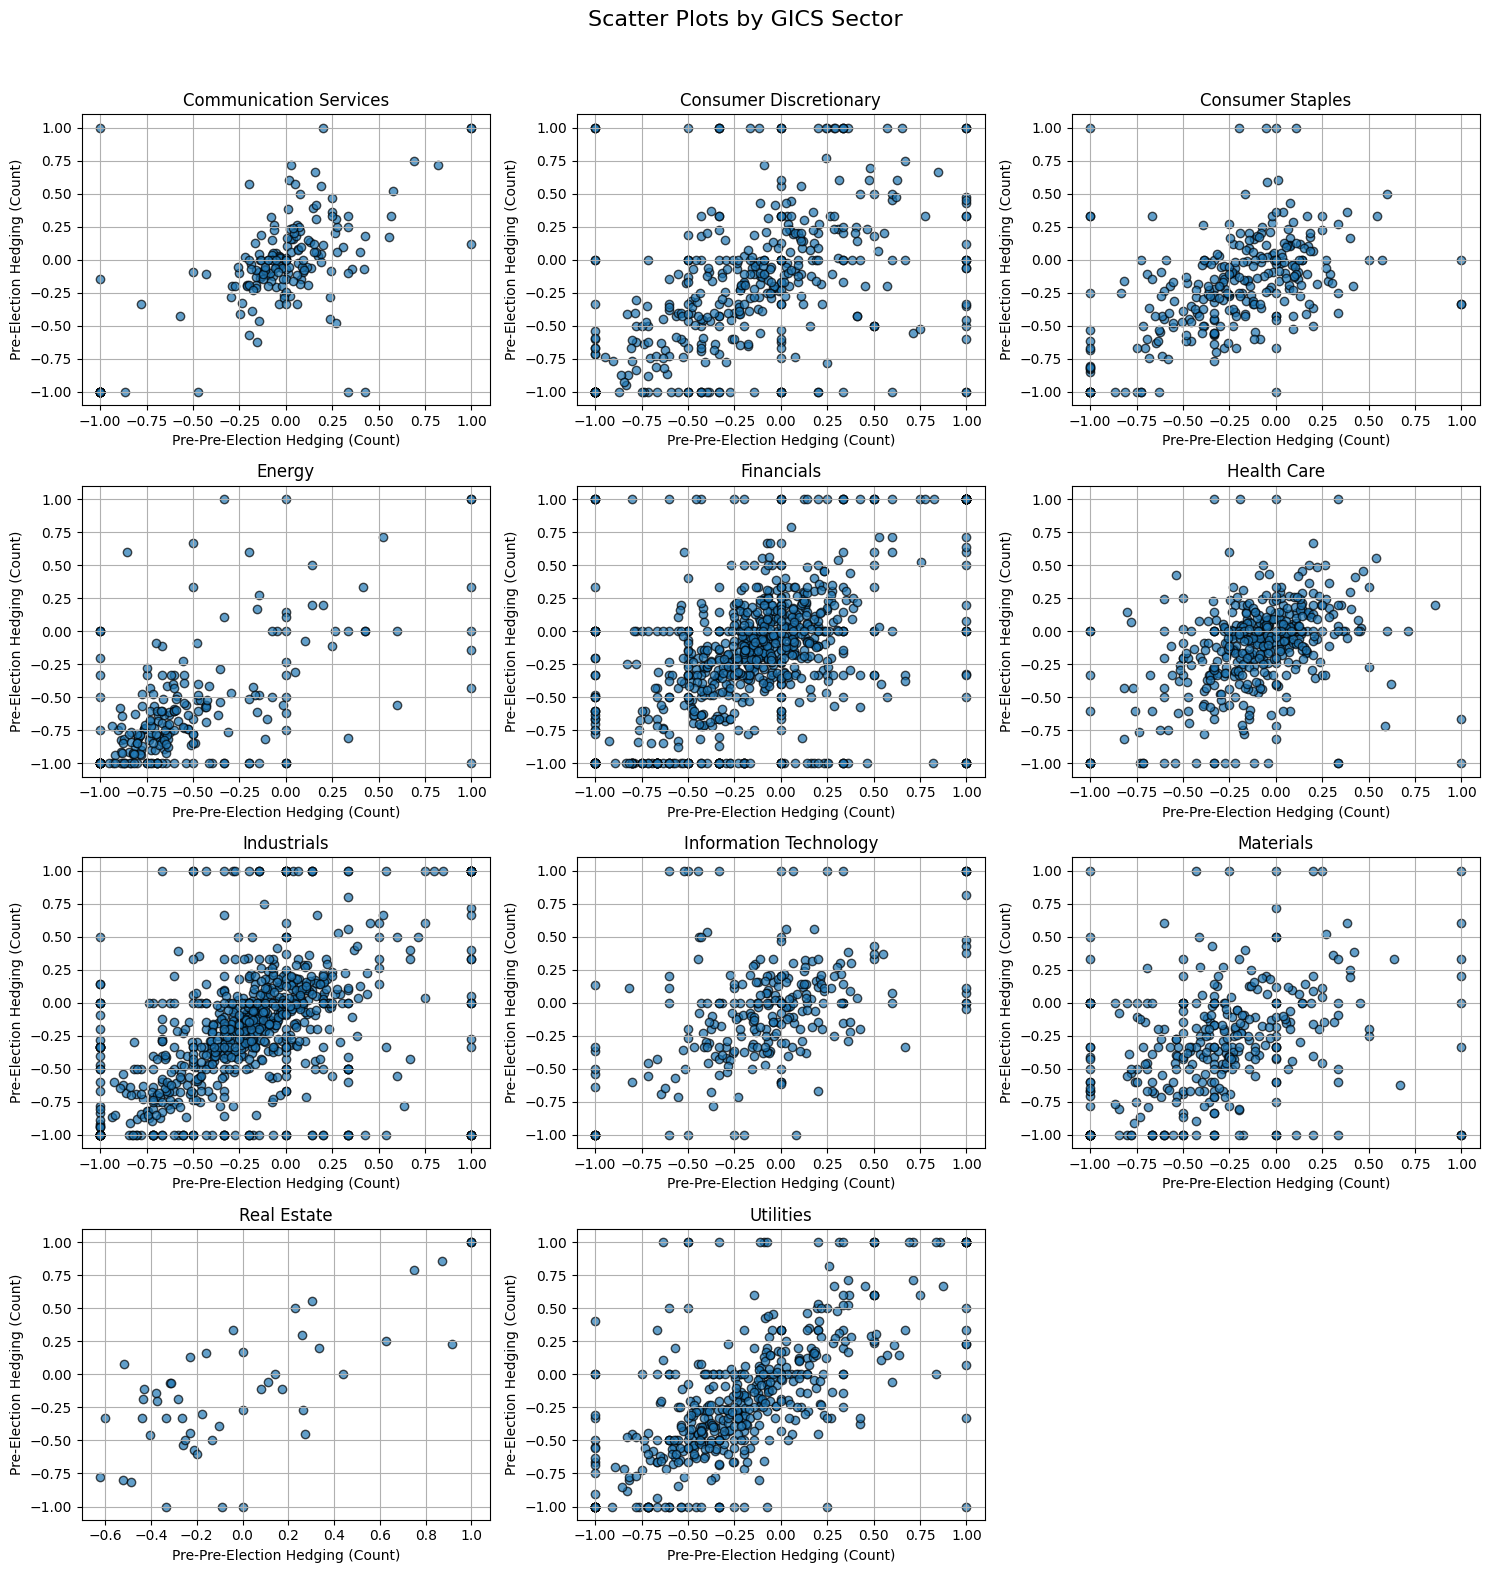

In [30]:
sectors = comparison['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = comparison[comparison['GICS_Sector'] == sector]
    ax.scatter(
        subset['balance_count_ppe'],
        subset['balance_count_pe'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Pre-Pre-Election Hedging (Count)')
    ax.set_ylabel('Pre-Election Hedging (Count)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

In [42]:
comparison = pd.merge(
    cpac_hedge_pe[["CMTE_ID", "YEAR", "GICS_Sector", "balance_amount", "balance_count"]],
    cpac_hedge_ppe[["CMTE_ID", "YEAR", "GICS_Sector", "balance_amount", "balance_count"]],
    how = "outer", on = ["CMTE_ID", "YEAR", "GICS_Sector"],
    suffixes = ("_pe", "_ppe")
)

In [38]:
comparison["hedge_change_count"] = abs(comparison["balance_amount_pe"]) - abs(comparison["balance_amount_ppe"])
comparison["hedge_change_amount"] = abs(comparison["balance_count_pe"]) - abs(comparison["balance_count_ppe"])
comparison["dem_change_count"] = (comparison["balance_amount_pe"]) - (comparison["balance_amount_ppe"])
comparison["dem_change_amount"] = (comparison["balance_count_pe"]) - (comparison["balance_count_ppe"])
comparison = pd.merge(cpac_hedge, comparison[["CMTE_ID", "YEAR",
                                              "hedge_change_count", "hedge_change_amount",
                                              "dem_change_count", "dem_change_amount"]])

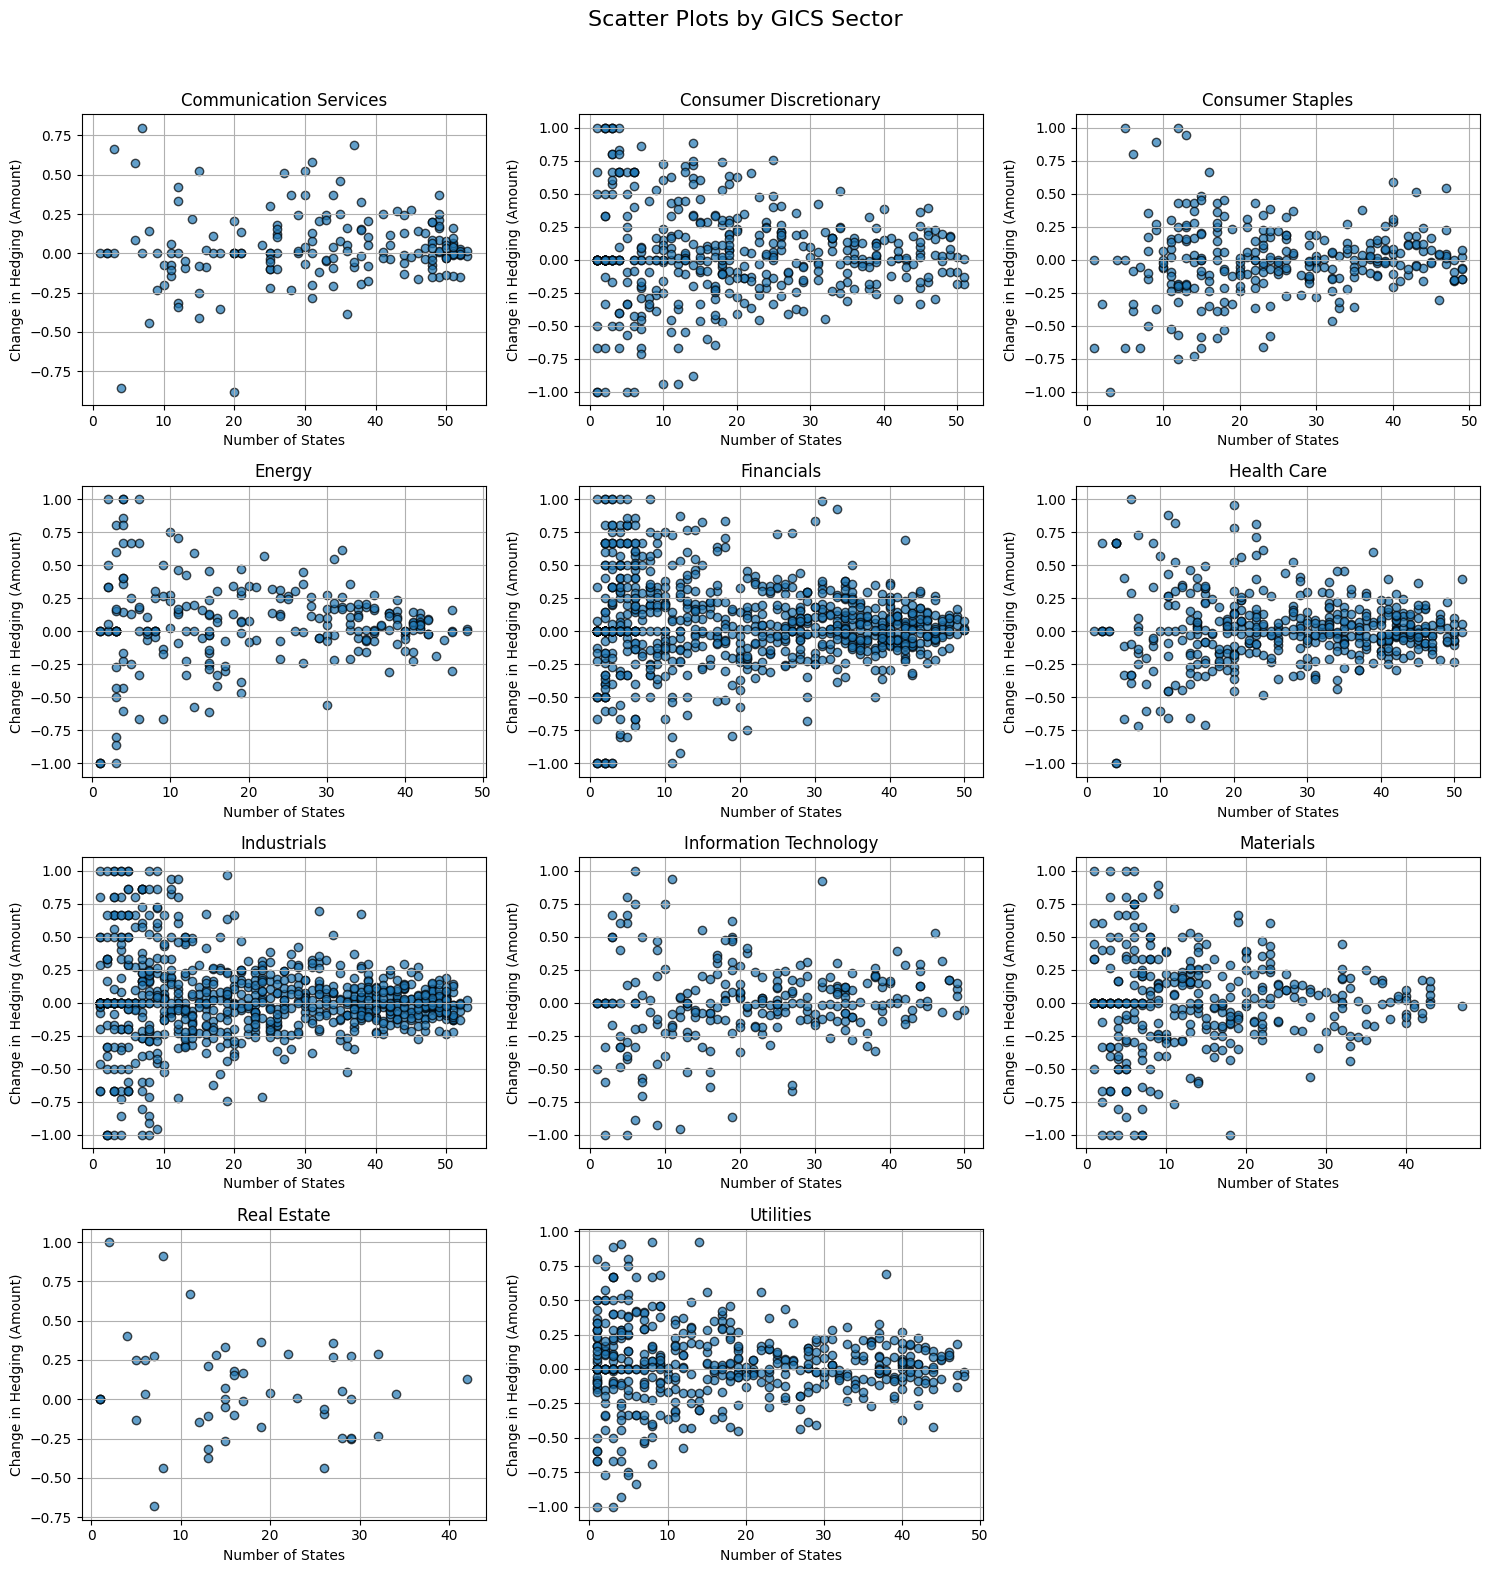

In [39]:
sectors = comparison['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = comparison[comparison['GICS_Sector'] == sector]
    ax.scatter(
        subset['n_states'],
        subset['hedge_change_amount'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Number of States')
    ax.set_ylabel('Change in Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

C:\Users\zih028\AppData\Local\Temp\ipykernel_4764\2618608168.py:8: DtypeWarning: Columns (10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")
C:\Users\zih028\AppData\Local\Temp\ipykernel_4764\2618608168.py:8: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")
C:\Users\zih028\AppData\Local\Temp\ipykernel_4764\2618608168.py:8: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")
C:\Users\zih028\AppData\Local\Temp\ipykernel_4764\2618608168.py:8: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv(f"../data/contributions/comm

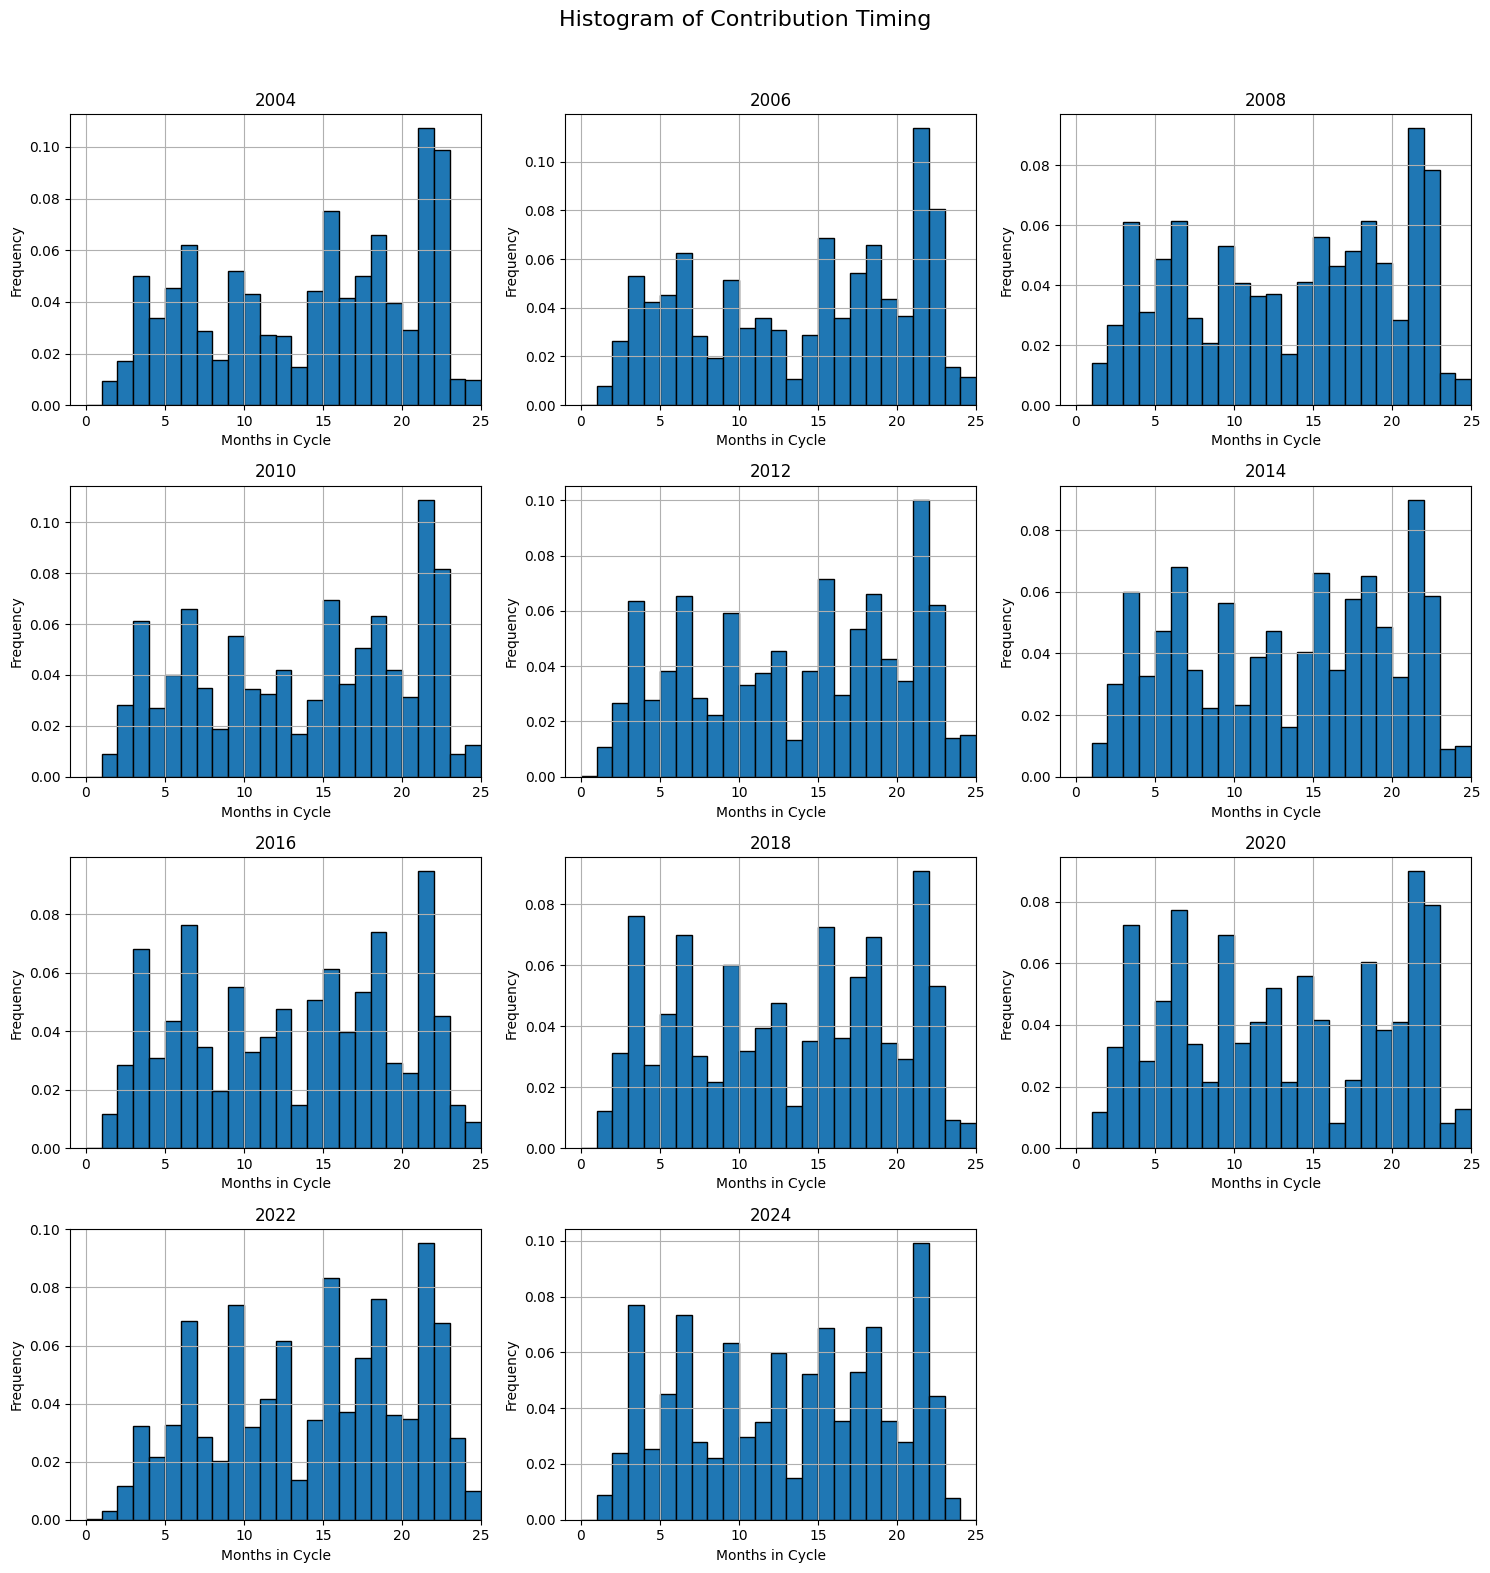

In [40]:
plots_per_row = 3
n_plots = len(range(2004, 2026, 2))
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, year in enumerate(range(2004, 2026, 2)):
    contrib = pd.read_csv(f"../data/contributions/committees/corp_candidate_{year}.csv")
    contrib = contrib.loc[contrib["TRANSACTION_TP"] == "24K", ]
    contrib["Month_Cycle"] = (contrib["YEAR"] - year + 1) * 12 + contrib["MONTH"]
    contrib = contrib.dropna(subset="Month_Cycle")

    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]

    ax.hist(contrib["Month_Cycle"], bins=np.arange(0, 26), edgecolor='black', density=True)
    ax.set_title(year)
    ax.set_xlim(-1, 25)
    ax.set_xlabel('Months in Cycle')
    ax.set_ylabel('Frequency')
    ax.grid(True)

for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Histogram of Contribution Timing', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

In [43]:
comparison

,CMTE_ID,YEAR,GICS_Sector,balance_amount_pe,balance_count_pe,balance_amount_ppe,balance_count_ppe
0,C00000042,2004,Industrials,-0.941176,-0.872340,-0.902913,-0.739130
1,C00000042,2006,Industrials,-1.000000,-1.000000,-0.889908,-0.826087
2,C00000042,2008,Industrials,-0.891892,-0.818182,-0.899160,-0.744681
3,C00000042,2010,Industrials,-0.951220,-0.906977,-0.919540,-0.837838
4,C00000042,2012,Industrials,-0.937984,-0.877551,-0.841808,-0.800000
...,...,...,...,...,...,...,...
14670,C00893925,2024,Energy,NaN,NaN,NaN,NaN
14671,C00893933,2024,NaN,NaN,NaN,NaN,NaN
14672,C00894055,2024,NaN,NaN,NaN,NaN,NaN
14673,C00894196,2024,Industrials,NaN,NaN,NaN,NaN


In [134]:
cpac_hedge_pe

,CMTE_ID,RIC,PermID,Parent,Website,YEAR,Instrument,CUSIP,ISIN,Common_Name,...,senate_hedge_amount,balance_count,balance_amount,house_balance_count,house_balance_amount,senate_balance_count,senate_balance_amount,contribute_sum,n_states,n_cands
0,C00000042,ITW.N,NaN,NaN,NaN,2004,ITW.N,452308109,US4523081093,Illinois Tool Works Inc,...,0.000000,-0.872340,-0.941176,-0.853659,-0.927536,-1.000000,-1.000000,96000.0,27.0,47.0
1,C00000042,ITW.N,NaN,NaN,NaN,2006,ITW.N,452308109,US4523081093,Illinois Tool Works Inc,...,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,68500.0,21.0,28.0
2,C00000042,ITW.N,NaN,NaN,NaN,2008,ITW.N,452308109,US4523081093,Illinois Tool Works Inc,...,0.105263,-0.818182,-0.891892,-0.851852,-0.890909,-0.666667,-0.894737,74000.0,21.0,33.0
3,C00000042,ITW.N,NaN,NaN,NaN,2010,ITW.N,452308109,US4523081093,Illinois Tool Works Inc,...,0.000000,-0.906977,-0.951220,-0.875000,-0.915789,-1.000000,-1.000000,82000.0,26.0,43.0
4,C00000042,ITW.N,NaN,NaN,NaN,2012,ITW.N,452308109,US4523081093,Illinois Tool Works Inc,...,0.000000,-0.877551,-0.937984,-0.828571,-0.887324,-1.000000,-1.000000,129000.0,30.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14670,C00892224,NaN,5071083761,NaN,NaN,2024,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14671,C00893370,NaN,5059100455,NaN,NaN,2024,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14672,C00893859,NaN,NaN,NaN,https://www.phronesisdc.com/,2024,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14673,C00893933,NaN,5034867214,NaN,NaN,2024,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
print(cand_2024["TRANSACTION_AMT"].sum())
print(cmte_2024["TRANSACTION_AMT"].sum())

136655876.0
97217162.0


In [151]:
committee = pd.read_parquet("../data/committees/committees_2024.parquet")

In [153]:
committee["CMTE_DSGN"].value_counts()

CMTE_DSGN
U    8529
P    8221
B    1521
J    1296
D     839
A     507
Name: count, dtype: Int64

In [159]:
committee.loc[(committee["CMTE_DSGN"] == "J"),]

,CMTE_ID,CMTE_NM,TRES_NM,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,CMTE_ZIP,CMTE_DSGN,CMTE_TP,CMTE_PTY_AFFILIATION,CMTE_FILING_FREQ,ORG_TP,CONNECTED_ORG_NM,CAND_ID
2589,C00415992,BLUMENAUER CENTURY FUND,"POMEROY, JULIA","1631 NE BROADWAY ST., #343",<NA>,PORTLAND,OR,97232,J,N,<NA>,T,V,<NA>,H6OR03064
2862,C00436998,WYDEN FOR OREGON,"MICHELS, F. STEPHEN",PO BOX 3271,<NA>,PORTLAND,OR,97208,J,N,<NA>,Q,<NA>,NONE,S6OR00110
2882,C00438481,COLE COMBINED COMMITTEE,"KEY, CLINTON E MR.",12176 CHANCERY STATION CIRCLE,<NA>,RESTON,VA,20190,J,N,<NA>,Q,M,COLE PAC/NRCC,H2OK04055
3146,C00460378,CORNYN MAJORITY COMMITTEE,"DAVIS, KEITH A.",228 S. WASHINGTON STREET,SUITE 115,ALEXANDRIA,VA,22314,J,N,<NA>,T,<NA>,<NA>,S2TX00106
3173,C00462333,HOUSE SENATE VICTORY FUND,"MATTHEWS, LAURA",120 MARYLAND AVE NE,<NA>,WASHINGTON,DC,20002,J,N,<NA>,Q,<NA>,NONE,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19633,C00892422,NEVADA STRONG,"HASTIE, CHRISSIE",3275 N FORT APACHE #150,<NA>,LAS VEGAS,NV,89129,J,N,<NA>,T,<NA>,<NA>,<NA>
19710,C00893230,LICCARDO VICTORY FUND,"NISSEN, MELISSA",600 PENNSYLVANIA AVE SE,UNIT 15180,WASHINGTON,DC,20003,J,N,<NA>,Q,<NA>,NONE,<NA>
19766,C00893826,DELUZIO RYAN 2026,"PETTERSON, JAY",122 C ST NW,STE 360,WASHINGTON,DC,20001,J,N,<NA>,Q,<NA>,NONE,<NA>
19811,C00894287,DEMS WIN,"MONTOYA, DACEY",1319 F ST NW STE 301,PMB 204,WASHINGTON,DC,20004,J,N,<NA>,Q,<NA>,NONE,<NA>
